In [1]:
!git clone https://github.com/theophile-bb/Reviews-sentiment.git

Cloning into 'Reviews-sentiment'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 51 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 5.31 MiB | 5.89 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [2]:
%cd Reviews-sentiment

/content/Reviews-sentiment


In [3]:
pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 91.2 MB/s eta 0:00:00


In [4]:
import sys
sys.path.append("src")

# Utils
from utils import *

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [5]:
path = "data/reviews.csv"

In [6]:
df = pd.read_csv(path)

In [7]:
df.head()

,address,categories,city,country,latitude,longitude,name,postalCode,province,reviews.date,reviews.dateAdded,reviews.doRecommend,reviews.id,reviews.rating,reviews.text,reviews.title,reviews.userCity,reviews.username,reviews.userProvince
0,Riviera San Nicol 11/a,Hotels,Mableton,US,45.421611,12.376187,Hotel Russo Palace,30126,GA,2013-09-22T00:00:00Z,2016-10-24T00:00:25Z,NaN,NaN,4.0,Pleasant 10 min walk along the sea front to th...,Good location away from the crouds,NaN,Russ (kent),NaN
1,Riviera San Nicol 11/a,Hotels,Mableton,US,45.421611,12.376187,Hotel Russo Palace,30126,GA,2015-04-03T00:00:00Z,2016-10-24T00:00:25Z,NaN,NaN,5.0,Really lovely hotel. Stayed on the very top fl...,Great hotel with Jacuzzi bath!,NaN,A Traveler,NaN
2,Riviera San Nicol 11/a,Hotels,Mableton,US,45.421611,12.376187,Hotel Russo Palace,30126,GA,2014-05-13T00:00:00Z,2016-10-24T00:00:25Z,NaN,NaN,5.0,Ett mycket bra hotell. Det som drog ner betyge...,Lugnt l��ge,NaN,Maud,NaN
3,Riviera San Nicol 11/a,Hotels,Mableton,US,45.421611,12.376187,Hotel Russo Palace,30126,GA,2013-10-27T00:00:00Z,2016-10-24T00:00:25Z,NaN,NaN,5.0,We stayed here for four nights in October. The...,Good location on the Lido.,NaN,Julie,NaN
4,Riviera San Nicol 11/a,Hotels,Mableton,US,45.421611,12.376187,Hotel Russo Palace,30126,GA,2015-03-05T00:00:00Z,2016-10-24T00:00:25Z,NaN,NaN,5.0,We stayed here for four nights in October. The...,������ ���������������,NaN,sungchul,NaN


 ### Data Preprocessing

We only keep the columns we need.

In [8]:
columnDict = {'reviews.title': 'title',
              'reviews.text': 'text',
              'reviews.rating': 'rating',
              'reviews.date': 'date'
}

review_df = data_processing(df, columnDict)

In [9]:
review_df.dtypes

,0
title,object
text,object
rating,float64
date,object


We convert dates to the right format

In [10]:
review_df = data_conversion(review_df)

In [11]:
review_df.dtypes

,0
title,object
text,object
rating,float64
date,"datetime64[ns, UTC]"


We remove comments with unreadable characters

In [12]:
textcol = 'text'
toReplace = '�'

review_df = text_processing(review_df, textcol, toReplace)

Let's take a look at a sample :

In [13]:
review_df.head()

,title,text,rating,date
0,Good location away from the crouds,Pleasant 10 min walk along the sea front to th...,4.0,2013-09-22 00:00:00+00:00
1,Great hotel with Jacuzzi bath!,Really lovely hotel. Stayed on the very top fl...,5.0,2015-04-03 00:00:00+00:00
2,Lugnt l��ge,Ett mycket bra hotell. Det som drog ner betyge...,5.0,2014-05-13 00:00:00+00:00
3,Good location on the Lido.,We stayed here for four nights in October. The...,5.0,2013-10-27 00:00:00+00:00
4,������ ���������������,We stayed here for four nights in October. The...,5.0,2015-03-05 00:00:00+00:00


In [14]:
len(review_df)

35874

***

### Tokenization & sentiment analysis

We call the pretrained RoBERTa transformer to get a label about sentiment (positive, negative, neutral) as well as a confidence score.

In [15]:
#sample = 100
col = 'text'
reviews_sentiment = get_sentiment(review_df, col)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


vocab.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cuda:0


In [16]:
reviews_sentiment

,title,text,rating,date,label,score
0,Good location away from the crouds,Pleasant 10 min walk along the sea front to th...,4.0,2013-09-22 00:00:00+00:00,positive,0.793500
1,Great hotel with Jacuzzi bath!,Really lovely hotel. Stayed on the very top fl...,5.0,2015-04-03 00:00:00+00:00,positive,0.985383
2,Lugnt l��ge,Ett mycket bra hotell. Det som drog ner betyge...,5.0,2014-05-13 00:00:00+00:00,neutral,0.836914
3,Good location on the Lido.,We stayed here for four nights in October. The...,5.0,2013-10-27 00:00:00+00:00,positive,0.939237
4,������ ���������������,We stayed here for four nights in October. The...,5.0,2015-03-05 00:00:00+00:00,positive,0.939237
...,...,...,...,...,...,...
35869,Amazing time (both times!!),Best of the Best!!!! My family and I stayed in...,5.0,2012-03-20 00:00:00+00:00,positive,0.986098
35870,Amazing time (both times!!),Amazing Vacation in Beautiful Cabin We stayed ...,5.0,2012-03-12 00:00:00+00:00,positive,0.985506
35871,Amazing time (both times!!),My husband and I stayed at Tree Tops which is ...,5.0,2015-11-03 00:00:00+00:00,positive,0.500543
35872,NaN,to share your opinion of this businesswith YP ...,0.0,NaT,neutral,0.889352


***

Now that we have the sentiment and score of the reviews we can process them with NLP technics

## Word Frequency

We calculate word frequency in order to plot a word cloud. To do so we clean the comments usig different techniques such as punctuation removal, stripping, stopwords removal and lemmatization.

In [17]:
reviews_sentiment = text_cleaning(reviews_sentiment, 'text')

In [18]:
reviews_sentiment

,title,text,rating,date,label,score
0,Good location away from the crouds,"[pleasant, 10, min, walk, sea, water, bus, res...",4.0,2013-09-22 00:00:00+00:00,positive,0.793500
1,Great hotel with Jacuzzi bath!,"[lovely, hotel, stay, floor, surprise, jacuzzi...",5.0,2015-04-03 00:00:00+00:00,positive,0.985383
2,Lugnt l��ge,"[ett, mycket, bra, hotell, det, som, drog, ner...",5.0,2014-05-13 00:00:00+00:00,neutral,0.836914
3,Good location on the Lido.,"[stay, night, october, hotel, staff, welcome, ...",5.0,2013-10-27 00:00:00+00:00,positive,0.939237
4,������ ���������������,"[stay, night, october, hotel, staff, welcome, ...",5.0,2015-03-05 00:00:00+00:00,positive,0.939237
...,...,...,...,...,...,...
35839,Amazing time (both times!!),"[good, good, family, stay, grin, bear, cabin, ...",5.0,2012-03-20 00:00:00+00:00,positive,0.986098
35840,Amazing time (both times!!),"[amazing, vacation, beautiful, cabin, stay, lo...",5.0,2012-03-12 00:00:00+00:00,positive,0.985506
35841,Amazing time (both times!!),"[husband, stay, tree, top, bearfoot, resort, m...",5.0,2015-11-03 00:00:00+00:00,positive,0.500543
35842,NaN,"[share, opinion, businesswith, yp, visitor, un...",0.0,NaT,neutral,0.889352


We get the words frequency and plot the word cloud

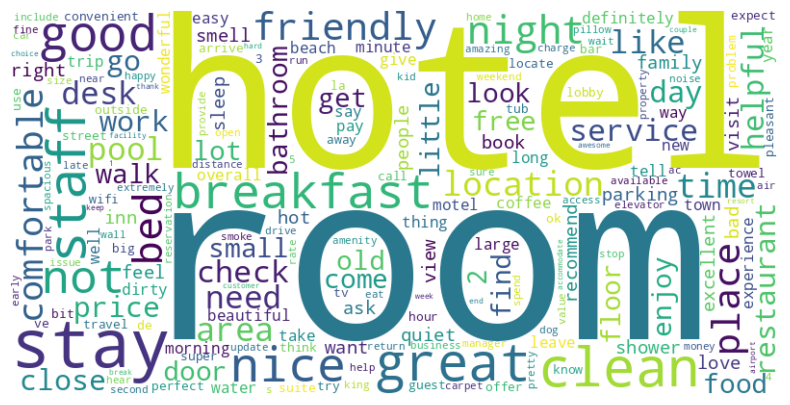

In [19]:
most_common_words = get_most_common_words(reviews_sentiment, 'text')
plot_wc(most_common_words)

## Most recurrent comments based on sentiment

Let's see the most recurrent words in negative reviews :

In [20]:
reviews_negative_sentiment = reviews_sentiment[reviews_sentiment['label'] == 'negative']

most_common_neg_words = get_most_common_words(reviews_negative_sentiment,'text')

In [21]:
reviews_positive_sentiment = reviews_sentiment[reviews_sentiment['label'] == 'positive']

most_common_pos_words = get_most_common_words(reviews_positive_sentiment,'text')

We compute the importance score for each word in negative reviews using the frequency in both positive and negative reviews.

In [22]:
negativeImportanceRatio = compute_importance_ratio(most_common_neg_words, most_common_pos_words)
positiveImportanceRatio = compute_importance_ratio(most_common_pos_words, most_common_neg_words)

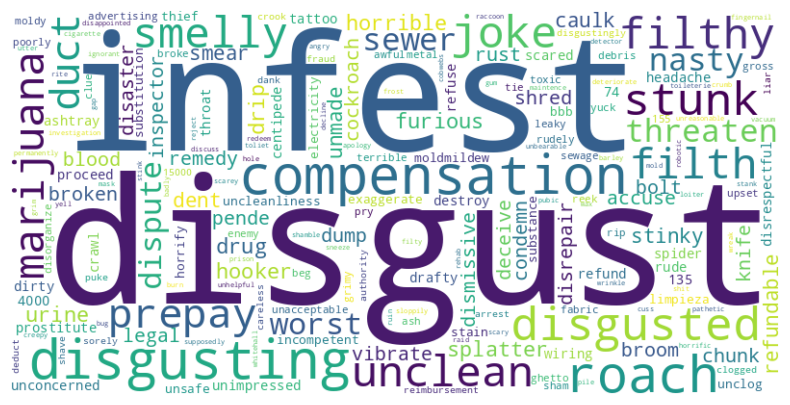

In [23]:
plot_wc(negativeImportanceRatio)

Let's now see for the positive reviews

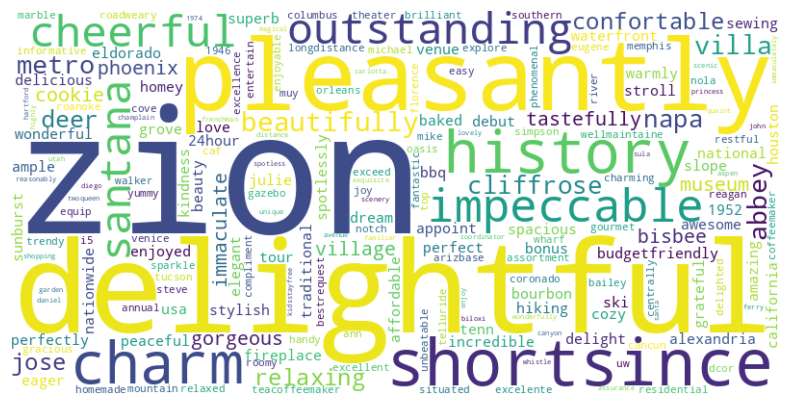

In [24]:
plot_wc(positiveImportanceRatio)

***

## Visualization

We can now display some quick visualizations to have a better overview of the reviews

In [25]:
reviews_sentiment.head(10)

,title,text,rating,date,label,score
0,Good location away from the crouds,"[pleasant, 10, min, walk, sea, water, bus, res...",4.0,2013-09-22 00:00:00+00:00,positive,0.793500
1,Great hotel with Jacuzzi bath!,"[lovely, hotel, stay, floor, surprise, jacuzzi...",5.0,2015-04-03 00:00:00+00:00,positive,0.985383
2,Lugnt l��ge,"[ett, mycket, bra, hotell, det, som, drog, ner...",5.0,2014-05-13 00:00:00+00:00,neutral,0.836914
3,Good location on the Lido.,"[stay, night, october, hotel, staff, welcome, ...",5.0,2013-10-27 00:00:00+00:00,positive,0.939237
4,������ ���������������,"[stay, night, october, hotel, staff, welcome, ...",5.0,2015-03-05 00:00:00+00:00,positive,0.939237
5,Very nice hotel,"[love, stay, island, lido, need, water, venice...",5.0,2015-04-05 00:00:00+00:00,positive,0.980950
6,Lovely view out onto the lagoon. Excellent view.,"[lovely, view, lagoon, excellent, view, staff,...",4.0,2014-06-10 00:00:00+00:00,positive,0.986510
7,Lovely view out onto the lagoon. Excellent view.,"[ottimo, soggiorno, e, ottima, sistemazione, n...",4.0,2015-05-14 00:00:00+00:00,neutral,0.694138
8,G��nstige Lage,"[gnstiger, ausgangspunkt, fr, venedig, besuche...",3.0,2015-09-14 00:00:00+00:00,neutral,0.739341
9,Ro og hygge,"[lidoen, er, perfekt, til, et, par, dage, ro, ...",4.0,2015-05-16 00:00:00+00:00,neutral,0.867289


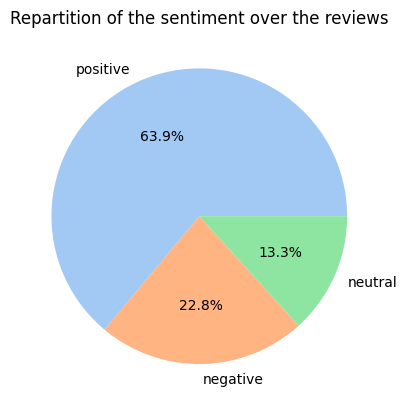

In [26]:
plot_pie(reviews_sentiment, 'label', 'Repartition of the sentiment over the reviews')

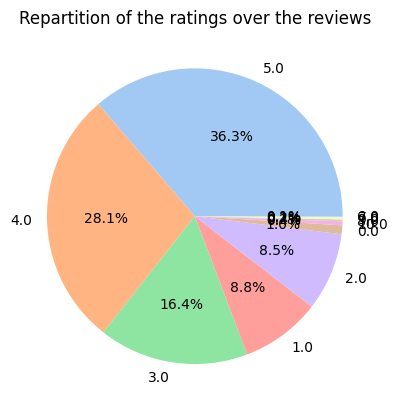

In [27]:
plot_pie(reviews_sentiment, 'rating', 'Repartition of the ratings over the reviews')

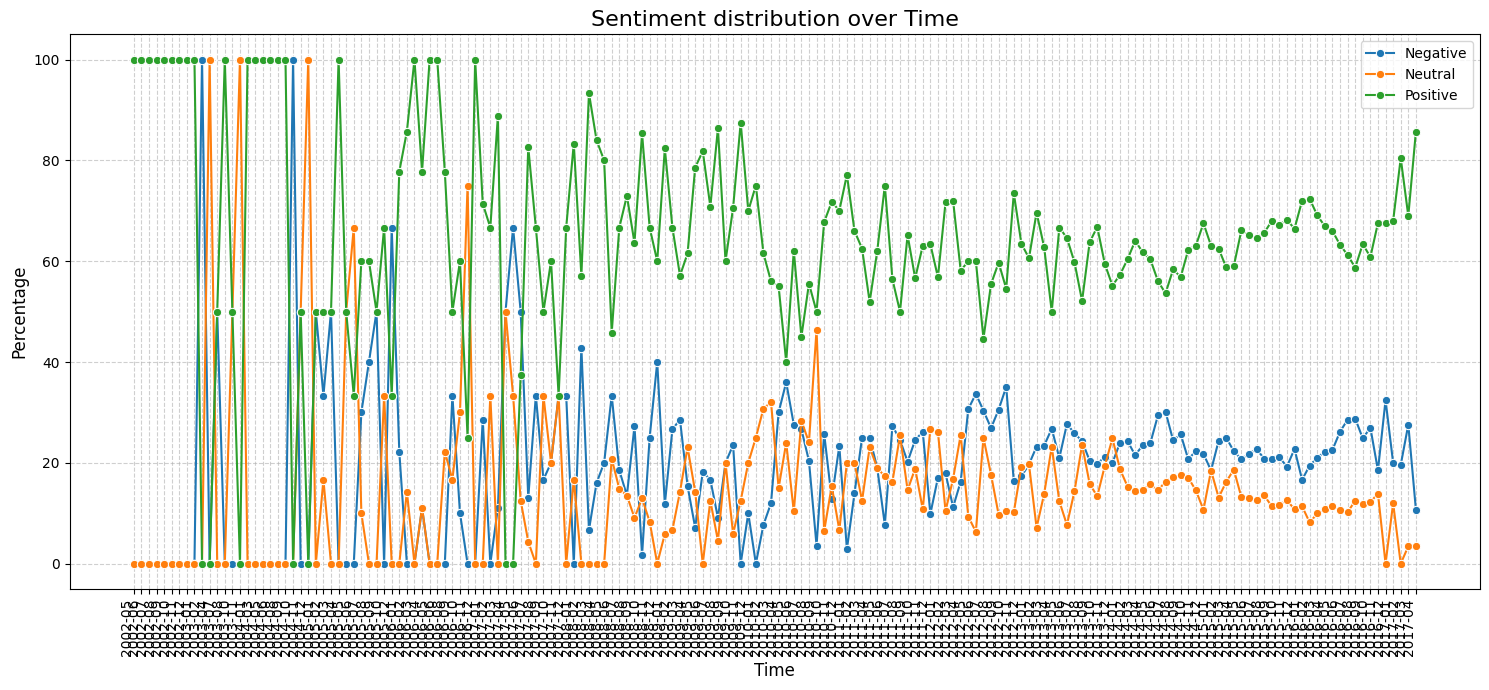

In [28]:
time_df = over_time(reviews_sentiment)
plot_graph(time_df,"Sentiment distribution over Time")

Calculate the correlation between
the sentiment and rating for the reviews.

Correlation :  0.25182810852517035


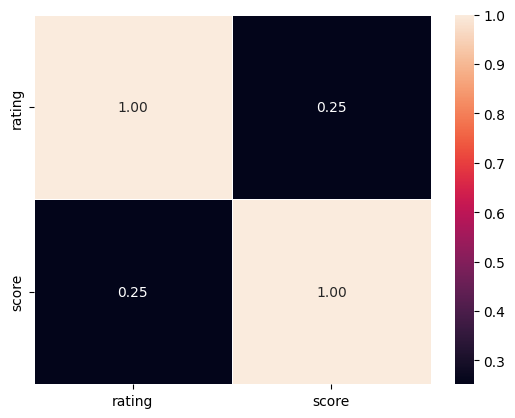

In [29]:
plot_correlation(reviews_sentiment)

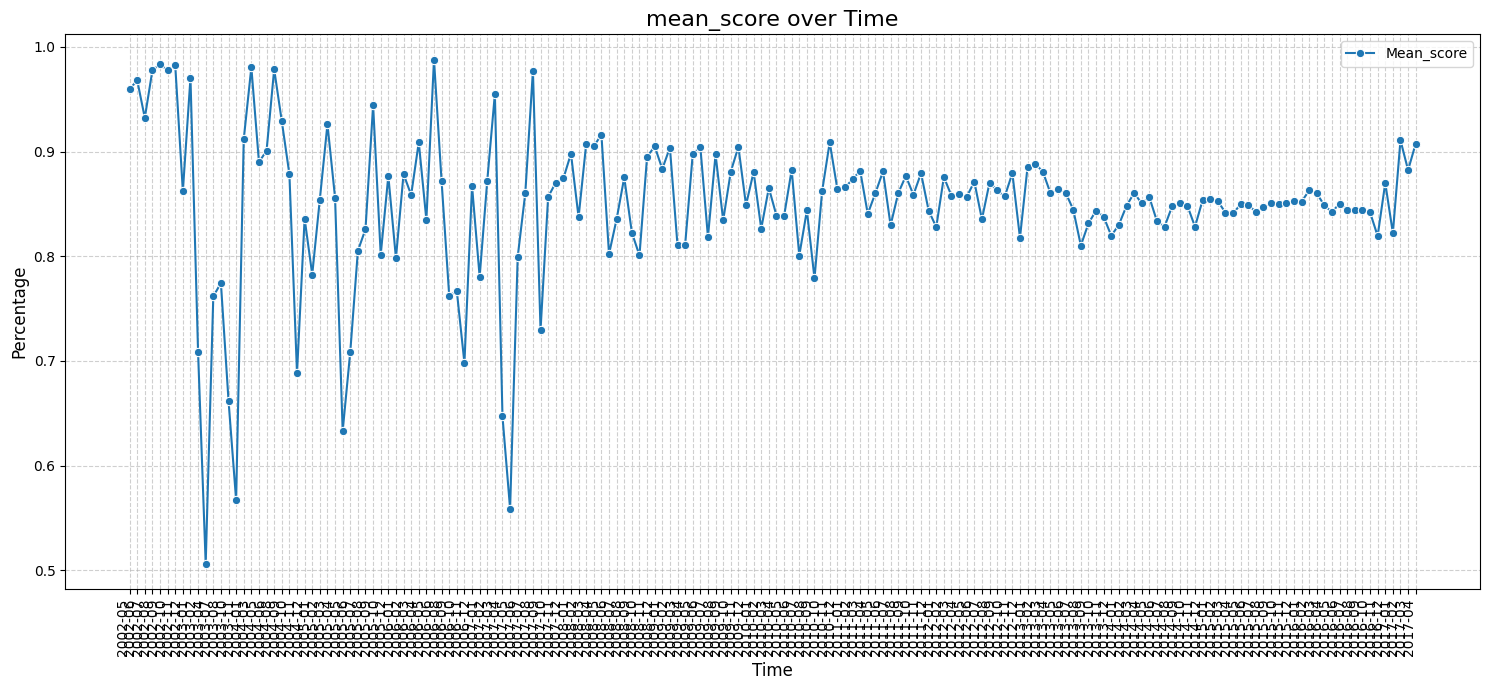

In [30]:
cols = ['mean_score']
title = f"{cols[0]} over Time"
plot_graph(time_df, title, cols)

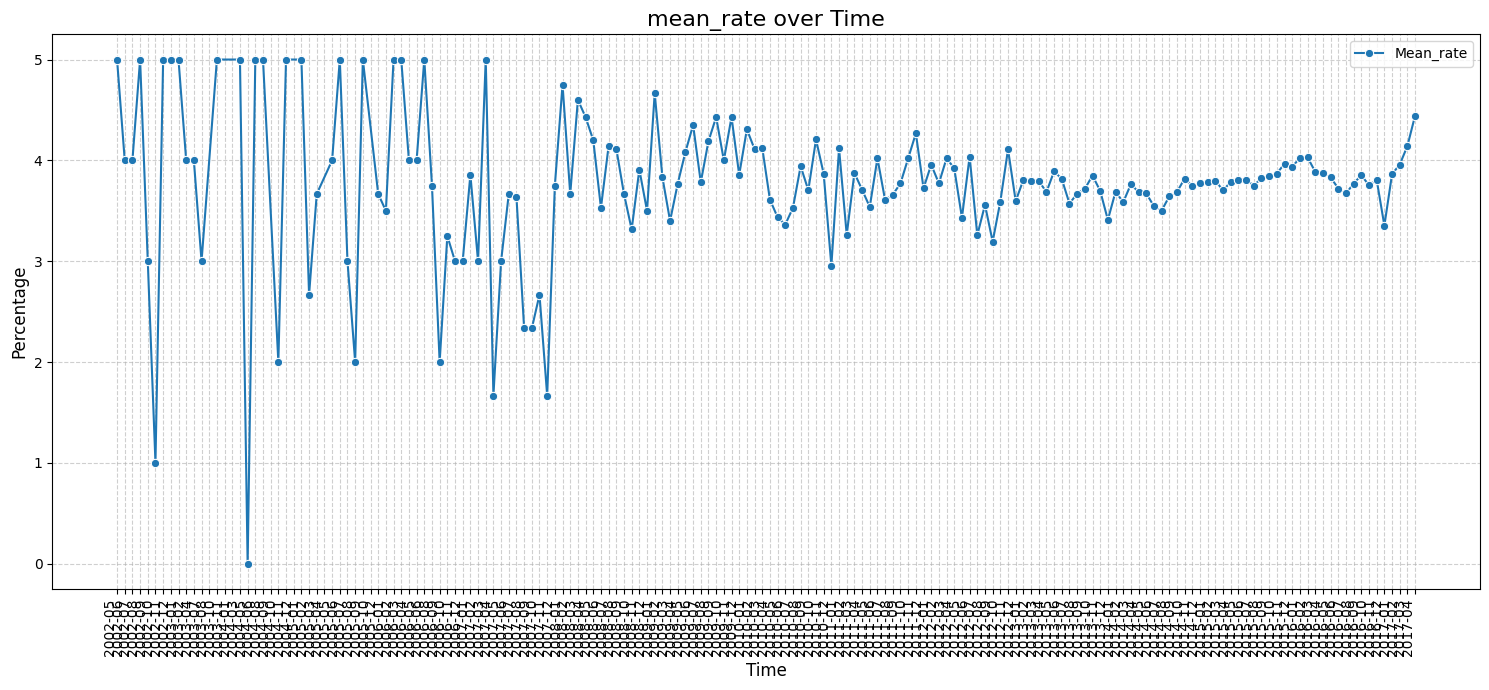

In [31]:
cols = ['mean_rate']
title = f"{cols[0]} over Time"
plot_graph(time_df, title, cols)

Now let's see how it goes when standaridizing

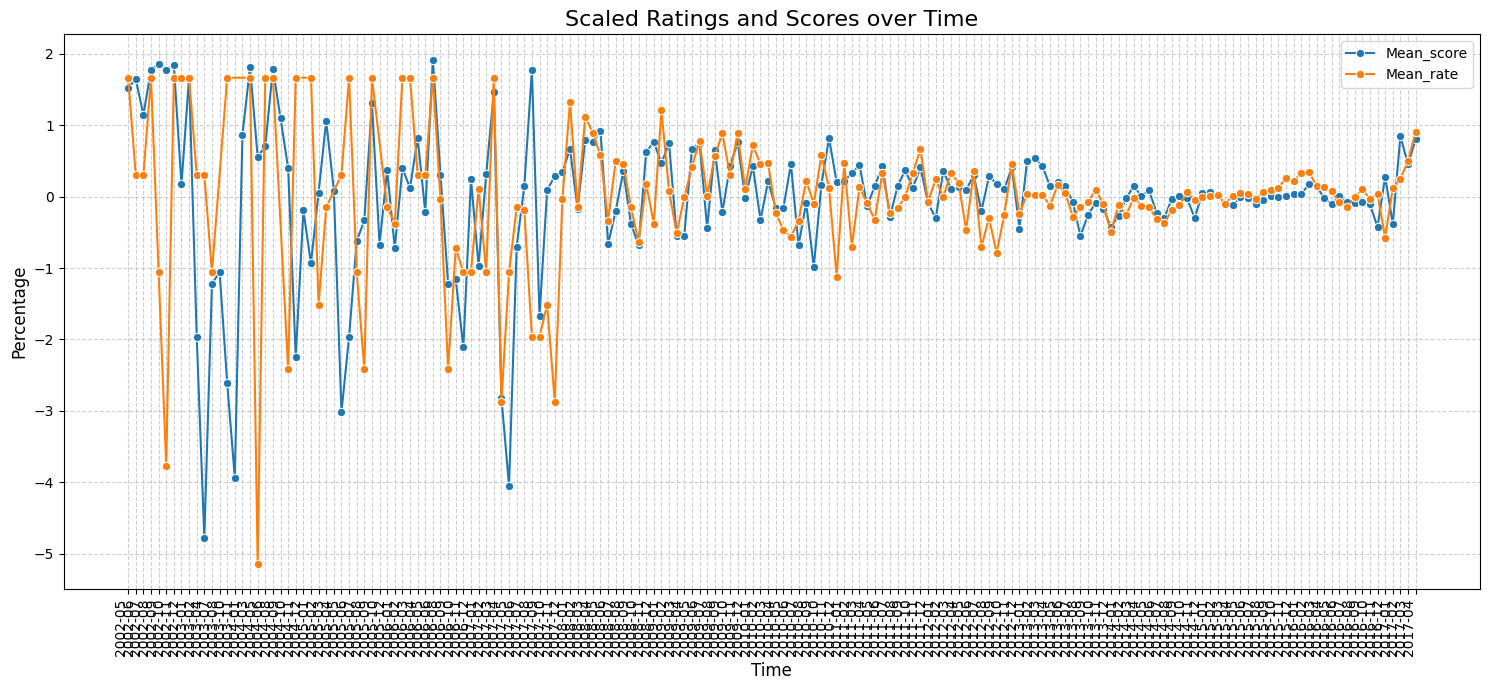

In [32]:
cols = ['mean_score', 'mean_rate']
time_df_scaled = scale_data(time_df, cols)

title = f"Scaled Ratings and Scores over Time"
plot_graph(time_df_scaled, title, cols)